# Import Library

In [13]:
import os
import numpy as np
import cv2
import shutil
import matplotlib.pyplot as plt
import random
from collections import Counter
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Konfigurasi Path

In [14]:
data_dir = '../data_clean'  
output_dir = '../data_split' 

# Buat folder output jika belum ada
os.makedirs(output_dir, exist_ok=True)

# Ukuran split (sesuaikan jika perlu)
train_size = 0.75
val_size = 0.15
test_size = 0.10

print("="*60)
print("KONFIGURASI SPLIT")
print("="*60)
print(f"Train size : {train_size*100:.0f}%")
print(f"Val size   : {val_size*100:.0f}%")
print(f"Test size  : {test_size*100:.0f}%")

KONFIGURASI SPLIT
Train size : 75%
Val size   : 15%
Test size  : 10%


# Load Dataset

In [15]:
def load_data(data_dir):
    images = []
    labels = []
    
    for label in os.listdir(data_dir):
        label_dir = os.path.join(data_dir, label)
        if not os.path.isdir(label_dir):
            continue
            
        print(f"Memuat kelas: {label}")
        for img_file in os.listdir(label_dir):
            if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
                
            img_path = os.path.join(label_dir, img_file)
            image = cv2.imread(img_path)
            if image is not None:
                images.append(image)
                labels.append(label)
    
    images = np.array(images)
    labels = np.array(labels)
    return images, labels

print("\n" + "="*60)
print("MEMUAT DATASET")
print("="*60)
images, labels = load_data(data_dir)
print(f"\n✅ Dataset dimuat:")
print(f"   Images shape: {images.shape}")
print(f"   Labels shape: {labels.shape}")
print(f"   Sample labels: {labels[:10]}")


MEMUAT DATASET
Memuat kelas: MildDemented
Memuat kelas: ModerateDemented
Memuat kelas: NonDemented
Memuat kelas: VeryMildDemented

✅ Dataset dimuat:
   Images shape: (12000, 224, 224, 3)
   Labels shape: (12000,)
   Sample labels: ['MildDemented' 'MildDemented' 'MildDemented' 'MildDemented'
 'MildDemented' 'MildDemented' 'MildDemented' 'MildDemented'
 'MildDemented' 'MildDemented']


# Eksplorasi Dataset Sebelum Split


📊 EKSPLORASI DATASET SEBELUM SPLIT

📈 DISTRIBUSI KELAS:
  MildDemented: 3000 gambar (25.0%)
  ModerateDemented: 3000 gambar (25.0%)
  NonDemented: 3000 gambar (25.0%)
  VeryMildDemented: 3000 gambar (25.0%)


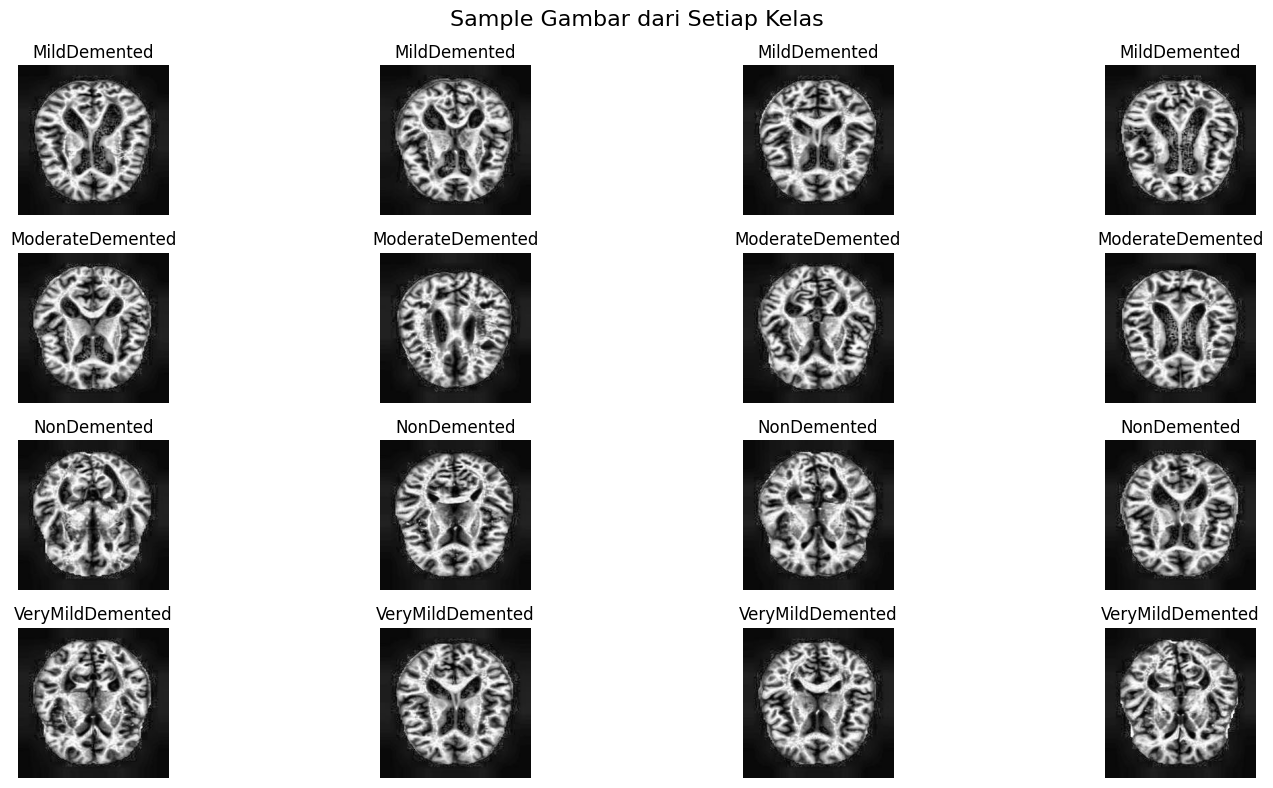


📏 Ukuran gambar: (224, 224, 3)
📊 Range pixel: [0, 255]


In [25]:
print("\n" + "="*60)
print("📊 EKSPLORASI DATASET SEBELUM SPLIT")
print("="*60)

# Hitung distribusi kelas
class_distribution = Counter(labels)
print("\n📈 DISTRIBUSI KELAS:")
for class_name, count in class_distribution.items():
    print(f"  {class_name}: {count} gambar ({count/len(labels)*100:.1f}%)")

# Tampilkan sample gambar dari setiap kelas
fig, axes = plt.subplots(4, 4, figsize=(16, 8))
fig.suptitle('Sample Gambar dari Setiap Kelas', fontsize=16)

unique_labels = list(class_distribution.keys())
for i, class_name in enumerate(unique_labels[:4]):  # Ambil 2 kelas pertama
    # Cari index gambar untuk kelas ini
    class_indices = [j for j, label in enumerate(labels) if label == class_name]
    sample_indices = random.sample(class_indices, min(4, len(class_indices)))
    
    for j, idx in enumerate(sample_indices):
        axes[i, j].imshow(cv2.cvtColor(images[idx], cv2.COLOR_BGR2RGB))
        axes[i, j].set_title(f'{class_name}')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

# Cek ukuran gambar
print(f"\n📏 Ukuran gambar: {images[0].shape}")
print(f"📊 Range pixel: [{images.min()}, {images.max()}]")

# Membuat Label

In [17]:
print("\n" + "="*60)
print("MEMBUAT LABEL ENCODING")
print("="*60)

label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
print(f"Labels encoded: {labels_encoded[:10]}")

# Convert integer labels to categorical format (one-hot encoding)
labels_categorical = to_categorical(labels_encoded)
print(f"Labels categorical shape: {labels_categorical.shape}")
print(f"Sample categorical:\n{labels_categorical[:5]}")


MEMBUAT LABEL ENCODING
Labels encoded: [0 0 0 0 0 0 0 0 0 0]
Labels categorical shape: (12000, 4)
Sample categorical:
[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]


# Validasi Label

In [18]:
print("\n" + "="*60)
print("✅ VALIDASI LABEL")
print("="*60)

# Tampilkan mapping label
print("\n📋 MAPPING LABEL:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {i}: {class_name}")

# Cek jumlah label per kelas setelah encoding
print("\n📊 DISTRIBUSI LABEL ENCODED:")
unique, counts = np.unique(labels_encoded, return_counts=True)
for label, count in zip(unique, counts):
    class_name = label_encoder.inverse_transform([label])[0]
    print(f"  {class_name} (label {label}): {count} gambar ({count/len(labels)*100:.1f}%)")


✅ VALIDASI LABEL

📋 MAPPING LABEL:
  0: MildDemented
  1: ModerateDemented
  2: NonDemented
  3: VeryMildDemented

📊 DISTRIBUSI LABEL ENCODED:
  MildDemented (label 0): 3000 gambar (25.0%)
  ModerateDemented (label 1): 3000 gambar (25.0%)
  NonDemented (label 2): 3000 gambar (25.0%)
  VeryMildDemented (label 3): 3000 gambar (25.0%)


# Split Data

In [19]:
def create_folder(path):
    if not os.path.exists(path):
        os.makedirs(path)

# Fungsi untuk membagi dataset dan menyimpan ke folder baru
def split_and_save_data(data_dir, output_dir, train_size=train_size, test_size=test_size, val_size=val_size, random_state=42):
    """
    Membagi dataset menjadi train/val/test dan menyimpan dalam struktur folder
    """
    # Pastikan ukuran split valid
    assert abs(train_size + test_size + val_size - 1.0) < 1e-10, "Total ukuran split harus 1.0 (100%)"

    # Buat folder output
    create_folder(output_dir)
    train_dir = os.path.join(output_dir, 'train')
    test_dir = os.path.join(output_dir, 'test')
    val_dir = os.path.join(output_dir, 'validation')
    create_folder(train_dir)
    create_folder(test_dir)
    create_folder(val_dir)

    print("\n" + "="*60)
    print("MEMBAGI DATASET")
    print("="*60)

    # Loop melalui setiap kelas di dataset
    for class_name in os.listdir(data_dir):
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):
            continue

        # Dapatkan daftar file gambar
        images = os.listdir(class_dir)
        images = [img for img in images if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if not images:
            continue

        print(f"\n📁 Kelas '{class_name}': {len(images)} gambar")

        # Bagi data menjadi train, test, dan validation
        train_images, test_val_images = train_test_split(
            images, 
            train_size=train_size, 
            random_state=random_state,
            shuffle=True
        )
        
        val_test_ratio = val_size / (val_size + test_size)
        val_images, test_images = train_test_split(
            test_val_images, 
            train_size=val_test_ratio, 
            random_state=random_state,
            shuffle=True
        )

        print(f"  Train: {len(train_images)} gambar")
        print(f"  Val: {len(val_images)} gambar")
        print(f"  Test: {len(test_images)} gambar")

        # Buat folder kelas di setiap subset
        create_folder(os.path.join(train_dir, class_name))
        create_folder(os.path.join(test_dir, class_name))
        create_folder(os.path.join(val_dir, class_name))

        # Salin gambar ke folder yang sesuai
        for img in train_images:
            shutil.copy(
                os.path.join(class_dir, img), 
                os.path.join(train_dir, class_name, img)
            )
        for img in test_images:
            shutil.copy(
                os.path.join(class_dir, img), 
                os.path.join(test_dir, class_name, img)
            )
        for img in val_images:
            shutil.copy(
                os.path.join(class_dir, img), 
                os.path.join(val_dir, class_name, img)
            )

        print(f"  ✅ Kelas '{class_name}' selesai diproses.")

    print("\n" + "="*60)
    print("✅ PROSES SPLIT SELESAI!")
    print("="*60)
    return train_dir, val_dir, test_dir

# Jalankan split
train_dir, val_dir, test_dir = split_and_save_data(
    data_dir, 
    output_dir, 
    train_size=train_size, 
    test_size=test_size, 
    val_size=val_size
)


MEMBAGI DATASET

📁 Kelas 'MildDemented': 3000 gambar
  Train: 2250 gambar
  Val: 450 gambar
  Test: 300 gambar
  ✅ Kelas 'MildDemented' selesai diproses.

📁 Kelas 'ModerateDemented': 3000 gambar
  Train: 2250 gambar
  Val: 450 gambar
  Test: 300 gambar
  ✅ Kelas 'ModerateDemented' selesai diproses.

📁 Kelas 'NonDemented': 3000 gambar
  Train: 2250 gambar
  Val: 450 gambar
  Test: 300 gambar
  ✅ Kelas 'NonDemented' selesai diproses.

📁 Kelas 'VeryMildDemented': 3000 gambar
  Train: 2250 gambar
  Val: 450 gambar
  Test: 300 gambar
  ✅ Kelas 'VeryMildDemented' selesai diproses.

✅ PROSES SPLIT SELESAI!


# Validasi Hasil Split


✅ VALIDASI HASIL SPLIT

📊 DISTRIBUSI DATA PER SPLIT:

TRAIN:
  MildDemented: 2250 gambar
  ModerateDemented: 2250 gambar
  NonDemented: 2250 gambar
  VeryMildDemented: 2250 gambar
  TOTAL: 9000 gambar

VALIDATION:
  MildDemented: 450 gambar
  ModerateDemented: 450 gambar
  NonDemented: 450 gambar
  VeryMildDemented: 450 gambar
  TOTAL: 1800 gambar

TEST:
  MildDemented: 300 gambar
  ModerateDemented: 300 gambar
  NonDemented: 300 gambar
  VeryMildDemented: 300 gambar
  TOTAL: 1200 gambar

📊 TOTAL GAMBAR:
  Dataset original : 12000 gambar
  Dataset setelah split: 12000 gambar
  ✅ SEMUA GAMBAR TERDISTRIBUSI DENGAN BAIK


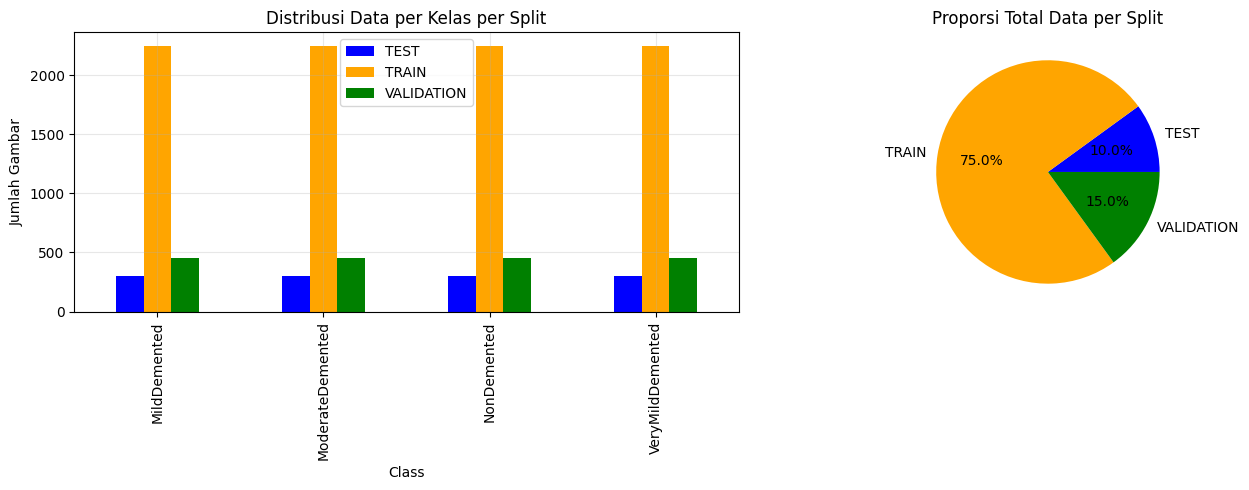

In [20]:
print("\n" + "="*60)
print("✅ VALIDASI HASIL SPLIT")
print("="*60)

# Fungsi untuk menghitung jumlah gambar per kelas di folder
def count_images_in_split(split_dir):
    counts = {}
    total = 0
    for class_name in os.listdir(split_dir):
        class_path = os.path.join(split_dir, class_name)
        if os.path.isdir(class_path):
            n_images = len([f for f in os.listdir(class_path) 
                           if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            counts[class_name] = n_images
            total += n_images
    return counts, total

# Validasi setiap split
splits = {
    'TRAIN': train_dir,
    'VALIDATION': val_dir,
    'TEST': test_dir
}

print("\n📊 DISTRIBUSI DATA PER SPLIT:")
total_all = 0
for split_name, split_dir in splits.items():
    if os.path.exists(split_dir):
        counts, total = count_images_in_split(split_dir)
        total_all += total
        print(f"\n{split_name}:")
        for class_name, count in counts.items():
            print(f"  {class_name}: {count} gambar")
        print(f"  TOTAL: {total} gambar")

# Validasi total gambar
total_original = len(images)

print(f"\n📊 TOTAL GAMBAR:")
print(f"  Dataset original : {total_original} gambar")
print(f"  Dataset setelah split: {total_all} gambar")

if total_original == total_all:
    print("  ✅ SEMUA GAMBAR TERDISTRIBUSI DENGAN BAIK")
else:
    print(f"  ⚠️ Ada selisih {abs(total_original - total_all)} gambar")

# Visualisasi distribusi data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot per kelas per split
data = []
for split_name, split_dir in splits.items():
    counts, _ = count_images_in_split(split_dir)
    for class_name, count in counts.items():
        data.append({'Split': split_name, 'Class': class_name, 'Count': count})

df = pd.DataFrame(data)
pivot_df = df.pivot(index='Class', columns='Split', values='Count')
pivot_df.plot(kind='bar', ax=axes[0], color=['blue', 'orange', 'green'])
axes[0].set_title('Distribusi Data per Kelas per Split')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Pie chart total per split
split_totals = df.groupby('Split')['Count'].sum()
axes[1].pie(split_totals.values, labels=split_totals.index, 
            autopct='%1.1f%%', colors=['blue', 'orange', 'green'])
axes[1].set_title('Proporsi Total Data per Split')

plt.tight_layout()
plt.show()

# Simpan Label Encoder

In [21]:
import pickle

# Simpan label encoder untuk digunakan saat inference nanti
encoder_path = os.path.join(output_dir, 'label_encoder.pkl')
with open(encoder_path, 'wb') as f:
    pickle.dump(label_encoder, f)

print("\n" + "="*60)
print("📝 LABEL ENCODER DISIMPAN")
print("="*60)
print(f"Classes: {label_encoder.classes_}")
print(f"Encoded: {label_encoder.transform(label_encoder.classes_)}")
print(f"Disimpan di: {encoder_path}")


📝 LABEL ENCODER DISIMPAN
Classes: ['MildDemented' 'ModerateDemented' 'NonDemented' 'VeryMildDemented']
Encoded: [0 1 2 3]
Disimpan di: ../data_split\label_encoder.pkl


# Ringkasan Split Data

In [22]:
print("\n" + "="*70)
print("📋 RINGKASAN SPLIT DATASET")
print("="*70)

print(f"\n📌 KONFIGURASI SPLIT:")
print(f"  Train size : {train_size*100:.0f}%")
print(f"  Val size   : {val_size*100:.0f}%")
print(f"  Test size  : {test_size*100:.0f}%")

print(f"\n📁 LOKASI OUTPUT:")
print(f"  {output_dir}/")
print(f"    ├── train/")
for class_name in sorted(os.listdir(train_dir)):
    if os.path.isdir(os.path.join(train_dir, class_name)):
        print(f"    │   ├── {class_name}/")
print(f"    ├── validation/")
for class_name in sorted(os.listdir(val_dir)):
    if os.path.isdir(os.path.join(val_dir, class_name)):
        print(f"    │   ├── {class_name}/")
print(f"    └── test/")
for class_name in sorted(os.listdir(test_dir)):
    if os.path.isdir(os.path.join(test_dir, class_name)):
        print(f"        ├── {class_name}/")


📋 RINGKASAN SPLIT DATASET

📌 KONFIGURASI SPLIT:
  Train size : 75%
  Val size   : 15%
  Test size  : 10%

📁 LOKASI OUTPUT:
  ../data_split/
    ├── train/
    │   ├── MildDemented/
    │   ├── ModerateDemented/
    │   ├── NonDemented/
    │   ├── VeryMildDemented/
    ├── validation/
    │   ├── MildDemented/
    │   ├── ModerateDemented/
    │   ├── NonDemented/
    │   ├── VeryMildDemented/
    └── test/
        ├── MildDemented/
        ├── ModerateDemented/
        ├── NonDemented/
        ├── VeryMildDemented/


# Simpan Informasi Split ke File

In [23]:
info_file = os.path.join(output_dir, 'split_info.txt')

with open(info_file, 'w') as f:
    f.write("="*60 + "\n")
    f.write("INFORMASI SPLIT DATASET\n")
    f.write("="*60 + "\n\n")
    
    f.write(f"Tanggal: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    
    f.write("KONFIGURASI SPLIT:\n")
    f.write(f"  Train size : {train_size*100:.0f}%\n")
    f.write(f"  Val size   : {val_size*100:.0f}%\n")
    f.write(f"  Test size  : {test_size*100:.0f}%\n\n")
    
    f.write("DISTRIBUSI DATA:\n")
    for split_name, split_dir in splits.items():
        if os.path.exists(split_dir):
            f.write(f"\n{split_name}:\n")
            counts, total = count_images_in_split(split_dir)
            for class_name, count in counts.items():
                f.write(f"  {class_name}: {count} gambar\n")
            f.write(f"  TOTAL: {total} gambar\n")
    
    f.write(f"\nLABEL ENCODER:\n")
    for i, class_name in enumerate(label_encoder.classes_):
        f.write(f"  {i}: {class_name}\n")
    
    f.write("\n" + "="*60 + "\n")

print(f"\n📁 Informasi split disimpan di: {info_file}")



📁 Informasi split disimpan di: ../data_split\split_info.txt
